In [7]:
import os,sys
#'..'是根据当前的cwd进行添加
#cwd是当前工作目录
#jupyter默认的的cwd是当前文件所在文件夹
#vscode的cwd是程序启动时所在目录,控制台有写,所以当我打开book2等文件的目录的父目录,cwd自动是那个父目录了
    #vscode中添加时候看好目录,所以上述情况只需'.'
    #'.'表示本文件夹'..'表示父文件夹,所以common是在book2的文件夹下,那时候就是cwd的本文件夹直接用'.'
#其他python库能够直接导入是疑问默认有那个关联路径

#如果文件是.py文件,当前文件夹可以不用使用path.append('.')添加当前目录,会自动添加
    #所以导入时候不需要添加 -文件名.库名 直接import 文件名就可以
    #如果common在book2中,已经是当前目录ch02的父目录book2了,需要使用path.append添加book2目录,条件按照上诉规则进行(注意cwd)
        #ch02已经是默认检索目录了,其中的模块直接导入模块名即可
    #添加后仅仅是book2为检索目录了,book2下的库(文件夹)内的文件无法自动提取,需要common.文件名提取(不会自动递归文件夹寻找)
sys.path.append('..')
import numpy as np
from common.util import preprocess

text = 'You say goodbye and I say hello.'
corpus,word_to_id,id_to_word = preprocess(text)

print(corpus)
print(id_to_word)

[0 1 2 3 4 1 5 6]
{0: 'you', 1: 'say', 2: 'goodbye', 3: 'and', 4: 'i', 5: 'hello', 6: '.'}


In [8]:
import os,sys
#__file__只存在于.py文件中这里是一个jupyter的cell,自然没有__file__.所以会报错
current_script_path = os.path.abspath(__file__)
current_dir = os.path.dirname(current_script_path)
parent_dir = os.path.dirname(current_dir)
sys.path.append(parent_dir)

NameError: name '__file__' is not defined

In [12]:
C = np.array([
    [0,1,0,0,0,0,0],
    [1,0,1,0,1,1,0],
    [0,1,0,1,0,0,0],
    [0,0,1,0,1,0,0],
    [0,1,0,1,0,0,0],
    [0,1,0,0,0,0,1],
    [0,0,0,0,0,1,0]
],dtype = np.int32)

In [14]:
C.dtype

dtype('int32')

In [15]:
print(C[0])

[0 1 0 0 0 0 0]


In [16]:
print(C[4])

[0 1 0 1 0 0 0]


In [17]:
print(C[word_to_id['goodbye']])

[0 1 0 1 0 0 0]


In [1]:
import numpy as np

C = np.array([
    [1, 2, 3],
    [4, 5, 6]
])

print("C =")
print(C)

print("C.shape =", C.shape)

print("\naxis=0：沿着第0维/行方向向下加")
print(np.sum(C, axis=0))
print("shape =", np.sum(C, axis=0).shape)

print("\naxis=1：沿着第1维/列方向横着加")
print(np.sum(C, axis=1))
print("shape =", np.sum(C, axis=1).shape)

C =
[[1 2 3]
 [4 5 6]]
C.shape = (2, 3)

axis=0：沿着第0维/行方向向下加
[5 7 9]
shape = (3,)

axis=1：沿着第1维/列方向横着加
[ 6 15]
shape = (2,)


[0 1 0 0 0 0 0]
[0.    1.807 0.    0.    0.    0.    0.   ]
[ 0.000e+00  3.409e-01 -3.886e-16 -1.205e-01  9.323e-01 -1.110e-16
 -1.467e-16]


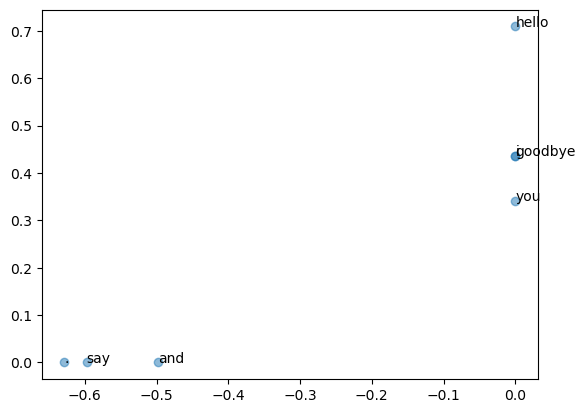

In [3]:
# coding: utf-8
import sys
sys.path.append('..')
import numpy as np
import matplotlib.pyplot as plt
from common.util import preprocess, create_co_matrix, ppmi


text = 'You say goodbye and I say hello.'
corpus, word_to_id, id_to_word = preprocess(text)
vocab_size = len(id_to_word)
C = create_co_matrix(corpus, vocab_size, window_size=1)
W = ppmi(C)

# SVD
U, S, V = np.linalg.svd(W)

np.set_printoptions(precision=3)  # 有效位数为3位
print(C[0])
print(W[0])
print(U[0])

# plot
for word, word_id in word_to_id.items():
    plt.annotate(word, (U[word_id, 0], U[word_id, 1]))#正确语法:annotate(word,(x,y))
plt.scatter(U[:,0], U[:,1], alpha=0.5)
plt.show()


In [4]:
S

array([3.168e+00, 3.168e+00, 2.703e+00, 2.703e+00, 1.514e+00, 1.514e+00,
       1.206e-16], dtype=float32)